<a href="https://colab.research.google.com/github/paulinamena/Integracion-de-datos-y-prospectiva/blob/main/Reto_2_Teor%C3%ADa_de_la_Credibilidad.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##**Integración de Datos**

En este espacio de trabajo se plantea como caso de estudio el proceso de integración de datos en una FINTECH que busca consolidar información proveniente de diferentes fuentes mediante el uso de métodos estadísticos especializados. El objetivo principal del negocio consiste en enriquecer y unificar sus bases de datos, garantizando que la información integrada sea confiable, consistente y útil para el análisis de pérdidas.

El proceso de integración se enfoca en la caracterización de la distribución agregada de pérdidas, la cual se analizará a partir de medidas de tendencia central y dispersión. De esta manera, el estudio se desarrolla considerando tres aspectos fundamentales:

Caracterización inicial: Se analizará la distribución agregada de pérdidas de las bases de datos utilizadas en la integración, empleando métricas como media, varianza y otros indicadores estadísticos.

Estimación de la credibilidad: Se evaluará la afinidad y confiabilidad de la base de datos externa frente a la base de datos interna, con el fin de determinar el peso que debe asignarse a cada fuente de información.

Integración de las bases: Posteriormente, se combinarán ambas fuentes y se realizará nuevamente la caracterización de la distribución agregada de pérdidas resultante del proceso.

Para el enriquecimiento de los datos se utilizará el método de Montecarlo, el cual permite simular el comportamiento de variables aleatorias a partir de sus histogramas de frecuencia, facilitando la generación de escenarios posibles. Asimismo, se aplicará la teoría de la credibilidad, que permite determinar el grado de confianza y afinidad entre las bases de datos mediante el análisis comparativo de sus medidas de tendencia central y dispersión, garantizando así una integración estadísticamente sólida.

0. Cargar las librerias de trabajo

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns #Esta libreria para el trabajo estadístico
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


1. Se cargan los archivos de trabajo

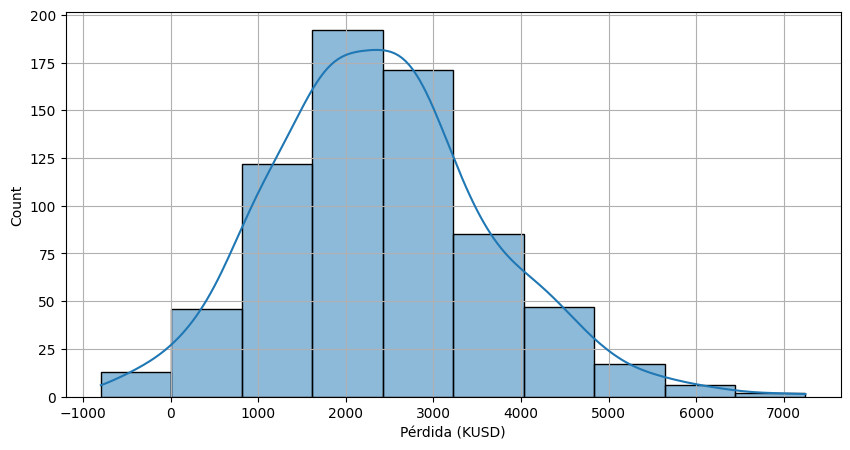

El número de datos por intervalo es:
[ 13  46 122 192 171  85  47  17   6   2]
Los intervalos inferiores:
[-796.592     7.6911  811.9742 1616.2573 2420.5404 3224.8235 4029.1066
 4833.3897 5637.6728 6441.9559]
Los intervalos superiores:
[   7.6911  811.9742 1616.2573 2420.5404 3224.8235 4029.1066 4833.3897
 5637.6728 6441.9559 7246.239 ]
La media es:  2407.3460267475034
El coeficiente de asimetría es:  0.3905534873601847


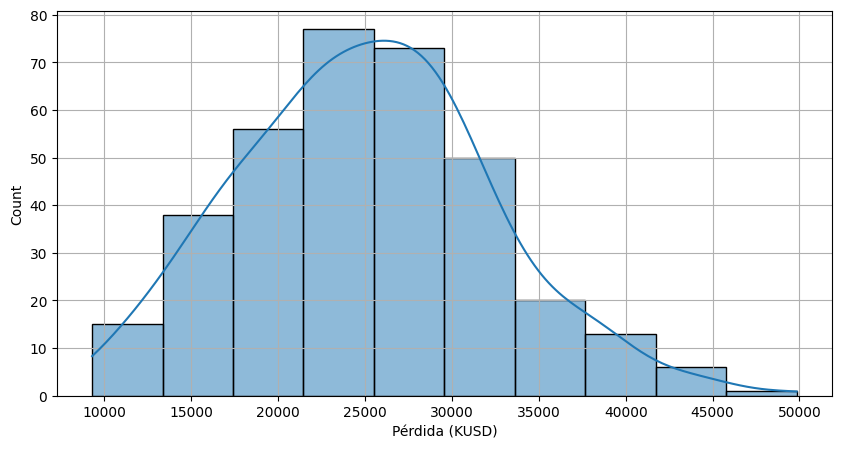

El número de datos por intervalo es:
[15 38 56 77 73 50 20 13  6  1]
Los intervalos inferiores:
[ 9298.9881  13352.84199 17406.69588 21460.54977 25514.40366 29568.25755
 33622.11144 37675.96533 41729.81922 45783.67311]
Los intervalos superiores:
[13352.84199 17406.69588 21460.54977 25514.40366 29568.25755 33622.11144
 37675.96533 41729.81922 45783.67311 49837.527  ]
La media es:  25160.1270306447
El coeficiente de asimetría es:  0.3905534873601847
La credibilidad de la base de datos externa es:  0.00023258678106663488
se conoce como la franquicia de las perdidas:  25154.83503455069


In [5]:
#-------------------------------------------------------------------------
#1. Aquí se carga la base de datos interna (datos observados)
#-------------------------------------------------------------------------
nxl='/content/drive/MyDrive/Integración de datos/reto 2/1. FallasTecnológicas.xlsx'
XDB=pd.read_excel(nxl,sheet_name=0)
XDB.head(10)

#Procedemos con la construcción de la distribución agregada de las pérdidas
# Extract data from the second row, convert to numeric, and drop any NaN values
Freq=pd.to_numeric(XDB.iloc[1:,1], errors='coerce').dropna()
Sev=pd.to_numeric(XDB.iloc[1:,2], errors='coerce').dropna()
LDA=Freq*Sev

#------------------------------------------------------------------------------------
#2. Se procede con la carga de la segunda base de datos (Datos externos - Hapag Loyd)
#------------------------------------------------------------------------------------
nxle='/content/drive/MyDrive/Integración de datos/reto 2/2. AdmonEjecProcesos.xlsx'
XDBe=pd.read_excel(nxle,sheet_name=0)
XDBe.head(10)

# Extract data from the second row, convert to numeric, and drop any NaN values
Freqe=pd.to_numeric(XDBe.iloc[1:,1], errors='coerce').dropna()
Seve=pd.to_numeric(XDBe.iloc[1:,2], errors='coerce').dropna()
LDAe=Freqe*Seve #Lo dividimos por 4 porque la base de datos interna está dividida en semanas y esta está es por mes, esntonces emparejamos los tiempos

#----------------------------------------------------------------------------
#3. Comparación estadística (Media, arianza, Desviación, Asímetria, Kurtosis)
#----------------------------------------------------------------------------
#3.1. Bases de datos observados (evergreen)
uo,sigmao,Caso,Kuro,dfo=caracterizacion(LDA) #Si no queremos que nos coloque un valor hacemos uo,sigmao,Caso,Kuro,_
print("La media es: ",uo)
print("El coeficiente de asimetría es: ",Caso)

#3.2. Bases de datos externas (hapag loyd)
ue,sigmae,Case,Kure,dfe=caracterizacion(LDAe)
print("La media es: ",ue)
print("El coeficiente de asimetría es: ",Caso)

#---------------------------------------------------------------------------
#4. Teoria de Credibilidad
#---------------------------------------------------------------------------
#4.1. Media Hipotetica
NDo=len(LDA); NDe=len(LDAe) #Para saber la inercia de loss datos
uhat=(uo*NDo+ue*NDe)/(NDo+NDe)

#4.2. EPV (Valor esperado de la varianza)
EPV=(NDo*sigmao**2+NDe*sigmae**2)/(NDo+NDe) #Determinar la varianza conjunta de los datos

#4.3. VHM: Varianza Hipotetica de la Media
VHM=((NDo*uo**2+NDe*ue**2)/(NDo+NDe))-uhat**2

#4.4. Factor de credibilidad
fc=EPV/VHM

#4.5. Credibilidad de la Base de Datos
Cr=1-(NDo/(NDo+fc))
print("La credibilidad de la base de datos externa es: ",Cr) #más que credibilidad es la afinidad de las bases de datos, si la base de datos tiene una afinidad del 75% o más con la mia significa que las puedo integrar. Si la base de datos tiene almenos un 1% de afinidad, significa que podemos integrar el 1% de los datos.

#------------------------------------------------------------------------------
#5. Parametros de riesgo
#------------------------------------------------------------------------------
#5.1 Perdidas Asumibles (Media:Franquicia) Media hipotetica de los datos integrados
PEs=Cr*uo+(1-Cr)*ue
print("se conoce como la franquicia de las perdidas: ",PEs)

**Analisis de credibilidad**

De acuerdo con el estudio, se puede observar que las medias son muy diferentes entre las bases (uo 2407.35, ue 25160.13), evidenciando que las perdidas externas se concentran en una escala mucho mayor. Sin embargo, ambas distribuciones tienen un coeficiente de asimetría igual (0.39), lo que indica una acumulación de pérdidas en valores bajos. A pesar de esto, el coeficiente de credibilidad obtenido es extremadamente bajo (0.023%), lo que indica que la base externa posee muy poca afinidad con la base interna y no se pueden integrar de manera significativa. La franquicia de perdidas de 25154.83 nos confirma que la base externa representa un nivel de perdidas más alto limitando su aporte a la integración.

2. Se procede con la clusterización estadística. La clusterización estadística esta definida por el Histograma de Frecuencias.

In [4]:
def caracterizacion(LDA):

  #Se procede con la creación de la distribución
  plt.figure(figsize=(10,5))
  sns.histplot(LDA,bins=10,kde=True)
  plt.xlabel("Pérdida (KUSD)")
  plt.grid()
  plt.show()

  #Se procede con la caracterización de cada una de las variables
  np.set_printoptions(suppress=True)
  NI=10    #Indica el número de clusters
  counts,bin_edges=np.histogram(LDA,bins=NI)
  print("El número de datos por intervalo es:")
  print(counts)
  print("Los intervalos inferiores:")
  print(bin_edges[:-1])
  print("Los intervalos superiores:")
  print(bin_edges[1:])
  XC=(bin_edges[:-1]+bin_edges[1:])/2

  #Se configura la tabla de los datos
  Tabla=np.column_stack((bin_edges[:-1],bin_edges[1:],XC,counts))
  df=pd.DataFrame(Tabla,columns=['LI','LS','XC','ND'])
  df.head(10)

  #Se procede con la estimación de la media
  fr=counts/np.sum(counts)
  u=np.sum(XC*fr)
  sigma2=np.sum(fr*(XC-u)**2)
  sigma=np.sqrt(sigma2)
  Cas=np.sum(fr*(XC-u)**3)/sigma**3
  Kur=(np.sum(fr*(XC-u)**4)/sigma**4)-3

  return u,sigma,Cas,Kur,df

3. Se calcular las métricas estadísticas de tendencia central y dispersión: Media, Desviación, Asimetría y Kurtosis

In [12]:

u=np.mean(LDA)
var=np.var(LDA)
sigma=np.std(LDA) # Corrected: Calculate standard deviation of LDA

T2=np.column_stack((u,var,sigma))
df2=pd.DataFrame(T2,columns=['Media','Varianza','Desviacion'])
df2.head(1)



,Media,Varianza,Desviacion
0,2391.636564,1.561393e+06,1249.557302


In [13]:
from scipy.stats import skew, kurtosis

# Calculate skewness
lda_skew = skew(LDA)

# Calculate kurtosis
lda_kurtosis = kurtosis(LDA)

# Optionally, add to the DataFrame with other metrics
df2_temp = df2.copy()
df2_temp['Asimetria'] = lda_skew
df2_temp['Kurtosis'] = lda_kurtosis

display(df2_temp)

,Media,Varianza,Desviacion,Asimetria,Kurtosis
0,2391.636564,1.561393e+06,1249.557302,0.408298,0.406849


**Analisis de Tendencias**

De las métricas de tendencia central y dispersión, podemos observar que los datos presentan una media de 2.391,64 y una desviación estándar de 1.249,56, lo que indica una variabilidad moderada alrededor del valor promedio de las pérdidas. El coeficiente de asimetría (0,4083) es positivo y menor que la unidad, lo que señala que los datos tienen una ligera inclinación hacia la derecha, evidenciando una mayor concentración de pérdidas por debajo de la media y la presencia de algunos valores altos poco frecuentes.

Por su parte, el coeficiente de curtosis (0,4068) muestra que la distribución es ligeramente leptocúrtica moderada, es decir, los datos presentan una concentración relativamente cercana a la media sin colas extremadamente pronunciadas. Esto sugiere que, en general, las pérdidas se mantienen en niveles esperados y no se observan eventos extremos significativamente alejados del comportamiento promedio.
